# Modelado, optimización y evaluación final de NO₂

Este notebook desarrolla la fase de modelado del proyecto de predicción de contaminación atmosférica en Madrid.

El objetivo es predecir la concentración diaria de **NO₂** de cada estación utilizando variables meteorológicas, de tráfico, temporales y observaciones históricas del propio contaminante.

## Contenido

1. Carga de los conjuntos oficiales.
2. Preparación de las variables.
3. Definición de la métrica principal.
4. Construcción de un baseline temporal.
5. Comparación de modelos mediante validación cruzada temporal.
6. Optimización de hiperparámetros.
7. Selección del modelo final.
8. Evaluación única sobre el conjunto de test.
9. Interpretación de los coeficientes.
10. Guardado del pipeline y de sus metadatos.

## 1. Metodología y prevención de data leakage

Para respetar el orden temporal del problema, el dataset fue dividido previamente en:

- **Train:** desde enero de 2019 hasta septiembre de 2023.
- **Test:** desde septiembre de 2023 hasta noviembre de 2024.

El conjunto de test se mantiene reservado durante la comparación y optimización de modelos. Solo se utiliza después de seleccionar definitivamente el modelo y sus hiperparámetros.

Dentro de train se aplica una validación cruzada temporal. En cada fold, el modelo aprende con un periodo pasado y se valida sobre un periodo posterior.

Las operaciones que necesitan aprender parámetros, como la imputación, el escalado y el One-Hot Encoding, se incluyen dentro de un `Pipeline`. De esta forma se ajustan exclusivamente con los datos de entrenamiento de cada fold.

### Escenario de predicción

Se plantea una predicción diaria de un paso hacia adelante.

El modelo utiliza la observación anterior disponible de NO₂ para cada estación. En la gran mayoría de los casos esta observación corresponde al día anterior, aunque pueden existir algunos saltos temporales por ausencia de registros.

La variable `no2_lag1` representa esta observación anterior y constituye también el baseline principal del proyecto.

In [1]:
# Librerías generales
import json
import time
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Herramientas de scikit-learn
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    HistGradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    TimeSeriesSplit,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

# El notebook puede ejecutarse desde la raíz del repositorio
# o desde la carpeta src/notebooks.
ROOT = Path.cwd()

if ROOT.name == "notebooks":
    ROOT = ROOT.parent.parent

RUTA_DATOS = ROOT / "src" / "data_sample"
RUTA_MODELOS = ROOT / "src" / "models"
RUTA_IMAGENES = ROOT / "src" / "img"

RUTA_MODELOS.mkdir(parents=True, exist_ok=True)
RUTA_IMAGENES.mkdir(parents=True, exist_ok=True)

print("Directorio raíz:", ROOT)

Matplotlib is building the font cache; this may take a moment.


Directorio raíz: /Users/victoriabiancon/Desktop/ML_Contaminacion_Madrid


## 2. Carga de los conjuntos oficiales

Se cargan los archivos generados por el pipeline de feature engineering.

La variable objetivo es `no2`.

In [2]:
train = pd.read_parquet(
    RUTA_DATOS / "train_fe.parquet"
)

test = pd.read_parquet(
    RUTA_DATOS / "test_fe.parquet"
)

train = train.sort_values(
    ["fecha", "estacion"]
).copy()

test = test.sort_values(
    ["fecha", "estacion"]
).copy()

resumen_datos = pd.DataFrame({
    "conjunto": ["train", "test"],
    "filas": [len(train), len(test)],
    "columnas": [train.shape[1], test.shape[1]],
    "fecha_inicio": [
        train["fecha"].min(),
        test["fecha"].min(),
    ],
    "fecha_fin": [
        train["fecha"].max(),
        test["fecha"].max(),
    ],
})

resumen_datos

,conjunto,filas,columnas,fecha_inicio,fecha_fin
0,train,40729,29,2019-01-01,2023-09-24
1,test,10272,29,2023-09-25,2024-11-30


## 3. Restauración de valores ausentes

Durante el feature engineering, `viento_vel` y `precipitacion` fueron imputadas con la mediana del conjunto completo de train.

Para que los primeros folds temporales no utilicen indirectamente una estadística de periodos futuros, se recuperan los valores ausentes originales mediante las variables:

- `viento_vel_missing`
- `precipitacion_missing`

Posteriormente, el pipeline calculará la mediana utilizando exclusivamente el train correspondiente a cada fold.

In [3]:
for datos in [train, test]:
    datos.loc[
        datos["viento_vel_missing"] == 1,
        "viento_vel"
    ] = np.nan

    datos.loc[
        datos["precipitacion_missing"] == 1,
        "precipitacion"
    ] = np.nan

nulos_train = (
    train.isna()
    .sum()
    .loc[lambda serie: serie > 0]
    .sort_values(ascending=False)
    .rename("nulos_train")
)

nulos_test = (
    test.isna()
    .sum()
    .loc[lambda serie: serie > 0]
    .sort_values(ascending=False)
    .rename("nulos_test")
)

pd.concat(
    [nulos_train, nulos_test],
    axis=1
).fillna(0).astype(int)

,nulos_train,nulos_test
viento_vel,29055,7261
precipitacion,22122,5557
ocupacion_mean,16164,4685
intensidad_mean,16151,4681
intensidad_max,16151,4681
carga_mean,16151,4681
vmed_mean,16151,4681
vmed_max,16151,4681
tipo_elem_moda,16151,4681
temperatura,5785,11


## 4. Selección de las variables

Se eliminan las filas que no disponen de `no2_lag1`, ya que el escenario definido requiere una observación histórica anterior.

Se excluyen las siguientes columnas del modelo:

- `fecha`: se utiliza para ordenar los datos y crear los cortes temporales.
- `no2`: es la variable objetivo.
- `estacion_no2_mean`: fue calculada utilizando el target completo de train antes de la validación cruzada. Mantenerla podría introducir data leakage.

Las variables `estacion`, `tipo_elem_moda` y `estacion_anio` se tratan como categóricas.

In [4]:
filas_train_iniciales = len(train)
filas_test_iniciales = len(test)

train = (
    train.dropna(subset=["no2_lag1"])
    .reset_index(drop=True)
)

test = (
    test.dropna(subset=["no2_lag1"])
    .reset_index(drop=True)
)

cobertura_train = len(train) / filas_train_iniciales
cobertura_test = len(test) / filas_test_iniciales

columnas_excluidas = [
    "fecha",
    "no2",
    "estacion_no2_mean",
]

variables_categoricas = [
    "estacion",
    "tipo_elem_moda",
    "estacion_anio",
]

variables_numericas = [
    columna
    for columna in train.columns
    if columna not in columnas_excluidas
    and columna not in variables_categoricas
]

variables_modelo = (
    variables_numericas
    + variables_categoricas
)

print(f"Cobertura de train: {cobertura_train:.2%}")
print(f"Cobertura de test: {cobertura_test:.2%}")

print("\nNúmero de variables numéricas:")
print(len(variables_numericas))

print("\nNúmero de variables categóricas:")
print(len(variables_categoricas))

print("\nVariables excluidas:")
print(columnas_excluidas)

Cobertura de train: 99.94%
Cobertura de test: 99.77%

Número de variables numéricas:
23

Número de variables categóricas:
3

Variables excluidas:
['fecha', 'no2', 'estacion_no2_mean']


In [5]:
print("Variables numéricas:")
print(variables_numericas)

print("\nVariables categóricas:")
print(variables_categoricas)

Variables numéricas:
['temperatura', 'humedad', 'viento_vel', 'precipitacion', 'intensidad_mean', 'intensidad_max', 'ocupacion_mean', 'carga_mean', 'vmed_mean', 'vmed_max', 'distancia_meteo_km', 'distancia_trafico_km', 'mes_sin', 'mes_cos', 'dia_anio_sin', 'dia_anio_cos', 'finde', 'no2_lag1', 'no2_lag7', 'no2_roll_mean_3', 'no2_roll_mean_7', 'viento_vel_missing', 'precipitacion_missing']

Variables categóricas:
['estacion', 'tipo_elem_moda', 'estacion_anio']


## 5. Métrica principal

La métrica principal seleccionada es el **MAE — Mean Absolute Error**.

El MAE expresa el error medio en las mismas unidades de la variable objetivo, es decir, en aproximadamente µg/m³ de NO₂. Además, es menos sensible que el RMSE a días puntuales con errores extremadamente altos.

Como métricas secundarias se utilizan:

- **RMSE:** penaliza con mayor intensidad los errores grandes.
- **R²:** indica qué proporción de la variabilidad del NO₂ es explicada por el modelo.

In [6]:
def calcular_metricas(y_real, y_pred):
    return {
        "MAE": mean_absolute_error(
            y_real,
            y_pred
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_real,
                y_pred
            )
        ),
        "R2": r2_score(
            y_real,
            y_pred
        ),
    }

## 6. Pipelines de preprocesamiento

Para los modelos lineales:

1. Los valores numéricos ausentes se imputan con la mediana.
2. Las variables numéricas se estandarizan.
3. Las variables categóricas se imputan con la moda.
4. Las categorías se transforman mediante One-Hot Encoding.

Para los modelos basados en árboles no se aplica escalado, ya que su funcionamiento no depende de la escala de las variables.

In [7]:
preprocesador_lineal = ColumnTransformer([
    (
        "numericas",
        Pipeline([
            (
                "imputacion",
                SimpleImputer(strategy="median")
            ),
            (
                "escalado",
                StandardScaler()
            ),
        ]),
        variables_numericas,
    ),
    (
        "categoricas",
        Pipeline([
            (
                "imputacion",
                SimpleImputer(strategy="most_frequent")
            ),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False
                )
            ),
        ]),
        variables_categoricas,
    ),
])

preprocesador_arboles = ColumnTransformer([
    (
        "numericas",
        SimpleImputer(strategy="median"),
        variables_numericas,
    ),
    (
        "categoricas",
        Pipeline([
            (
                "imputacion",
                SimpleImputer(strategy="most_frequent")
            ),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False
                )
            ),
        ]),
        variables_categoricas,
    ),
])

## 7. Validación cruzada temporal

Se utilizan cuatro folds temporales.

Las fechas se separan antes de seleccionar las filas para garantizar que todas las estaciones de un mismo día permanezcan en el mismo fold.

En cada iteración:

- El train contiene solamente fechas anteriores.
- La validación contiene un periodo posterior.
- Ningún dato futuro se utiliza para entrenar el modelo.

In [8]:
fechas_train_disponibles = np.array(
    sorted(train["fecha"].unique())
)

tscv = TimeSeriesSplit(n_splits=4)

folds_temporales = []

for idx_train_fecha, idx_validacion_fecha in tscv.split(
    fechas_train_disponibles
):
    fechas_fold_train = fechas_train_disponibles[
        idx_train_fecha
    ]

    fechas_fold_validacion = fechas_train_disponibles[
        idx_validacion_fecha
    ]

    indices_train = np.flatnonzero(
        train["fecha"]
        .isin(fechas_fold_train)
        .to_numpy()
    )

    indices_validacion = np.flatnonzero(
        train["fecha"]
        .isin(fechas_fold_validacion)
        .to_numpy()
    )

    folds_temporales.append(
        (indices_train, indices_validacion)
    )

periodos_folds = []

for numero, (
    indices_train,
    indices_validacion
) in enumerate(folds_temporales, start=1):
    periodos_folds.append({
        "fold": numero,
        "train_inicio": train.loc[
            indices_train,
            "fecha"
        ].min(),
        "train_fin": train.loc[
            indices_train,
            "fecha"
        ].max(),
        "validacion_inicio": train.loc[
            indices_validacion,
            "fecha"
        ].min(),
        "validacion_fin": train.loc[
            indices_validacion,
            "fecha"
        ].max(),
        "filas_train": len(indices_train),
        "filas_validacion": len(indices_validacion),
    })

pd.DataFrame(periodos_folds)

,fold,train_inicio,train_fin,validacion_inicio,validacion_fin,filas_train,filas_validacion
0,1,2019-01-02,2019-12-14,2019-12-15,2020-11-23,8237,8177
1,2,2019-01-02,2020-11-23,2020-11-24,2021-11-03,16414,8183
2,3,2019-01-02,2021-11-03,2021-11-04,2022-10-14,24597,7983
3,4,2019-01-02,2022-10-14,2022-10-15,2023-09-24,32580,8125


## 8. Baseline y comparación inicial de modelos

El baseline consiste en utilizar como predicción la última observación disponible de NO₂ de la misma estación.

Se comparan tres familias de modelos:

- **Ridge:** modelo lineal con regularización L2.
- **Random Forest:** conjunto de árboles de decisión.
- **HistGradientBoosting:** modelo de boosting basado en árboles.

El baseline permite comprobar si los modelos aportan realmente valor frente a una regla temporal sencilla.

In [9]:
modelos_iniciales = {
    "Ridge": Pipeline([
        (
            "preprocesado",
            preprocesador_lineal
        ),
        (
            "modelo",
            Ridge(alpha=10.0)
        ),
    ]),

    "Random Forest": Pipeline([
        (
            "preprocesado",
            preprocesador_arboles
        ),
        (
            "modelo",
            RandomForestRegressor(
                n_estimators=100,
                min_samples_leaf=2,
                random_state=42,
                n_jobs=-1
            )
        ),
    ]),

    "HistGradientBoosting": Pipeline([
        (
            "preprocesado",
            preprocesador_arboles
        ),
        (
            "modelo",
            HistGradientBoostingRegressor(
                max_iter=200,
                learning_rate=0.05,
                random_state=42
            )
        ),
    ]),
}

In [10]:
resultados_iniciales = []

for fold, (
    indices_train,
    indices_validacion
) in enumerate(folds_temporales, start=1):

    datos_train_fold = train.loc[
        indices_train
    ].copy()

    datos_validacion_fold = train.loc[
        indices_validacion
    ].copy()

    X_train_fold = datos_train_fold[
        variables_modelo
    ]

    y_train_fold = datos_train_fold["no2"]

    X_validacion_fold = datos_validacion_fold[
        variables_modelo
    ]

    y_validacion_fold = datos_validacion_fold["no2"]

    pred_baseline = datos_validacion_fold[
        "no2_lag1"
    ]

    resultados_iniciales.append({
        "fold": fold,
        "modelo": "Baseline lag1",
        **calcular_metricas(
            y_validacion_fold,
            pred_baseline
        ),
        "tiempo_segundos": 0.0,
    })

    for nombre, modelo_base in modelos_iniciales.items():
        modelo = clone(modelo_base)

        inicio = time.time()

        modelo.fit(
            X_train_fold,
            y_train_fold
        )

        predicciones = modelo.predict(
            X_validacion_fold
        )

        resultados_iniciales.append({
            "fold": fold,
            "modelo": nombre,
            **calcular_metricas(
                y_validacion_fold,
                predicciones
            ),
            "tiempo_segundos": time.time() - inicio,
        })

resultados_iniciales_df = pd.DataFrame(
    resultados_iniciales
)

resultados_iniciales_df

,fold,modelo,MAE,RMSE,R2,tiempo_segundos
0,1,Baseline lag1,7.652073,10.735818,0.660932,0.000000
1,1,Ridge,7.121334,9.312016,0.744904,0.055090
2,1,Random Forest,7.432090,9.768266,0.719294,1.782439
3,1,HistGradientBoosting,7.838277,10.277545,0.689261,6.157058
4,2,Baseline lag1,8.109006,10.785466,0.579341,0.000000
5,2,Ridge,7.235294,9.666579,0.662092,0.114799
6,2,Random Forest,7.355971,10.003936,0.638095,4.447368
7,2,HistGradientBoosting,7.406889,10.199248,0.623826,7.847394
8,3,Baseline lag1,8.423024,11.412423,0.473024,0.000000
9,3,Ridge,7.031565,9.453450,0.638410,0.157117


In [11]:
resumen_inicial = (
    resultados_iniciales_df
    .groupby("modelo")
    .agg(
        MAE_medio=("MAE", "mean"),
        MAE_std=("MAE", "std"),
        RMSE_medio=("RMSE", "mean"),
        R2_medio=("R2", "mean"),
        tiempo_medio=(
            "tiempo_segundos",
            "mean"
        ),
    )
    .sort_values("MAE_medio")
    .reset_index()
)

resumen_inicial

,modelo,MAE_medio,MAE_std,RMSE_medio,R2_medio,tiempo_medio
0,Ridge,7.051028,0.177531,9.310807,0.656566,0.129354
1,Random Forest,7.221886,0.205647,9.606702,0.634800,4.872430
2,HistGradientBoosting,7.233801,0.499985,9.624946,0.637931,6.239453
3,Baseline lag1,7.953041,0.383581,10.809730,0.534990,0.000000


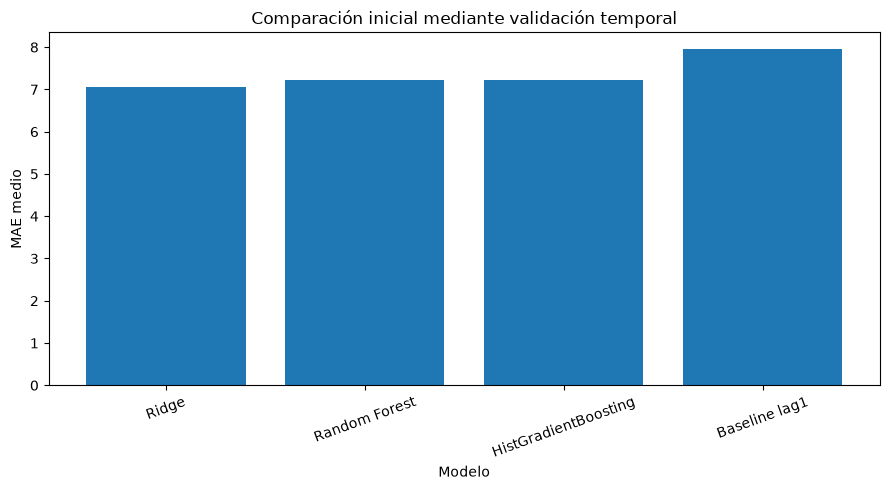

In [12]:
figura, eje = plt.subplots(
    figsize=(9, 5)
)

eje.bar(
    resumen_inicial["modelo"],
    resumen_inicial["MAE_medio"]
)

eje.set_title(
    "Comparación inicial mediante validación temporal"
)
eje.set_ylabel("MAE medio")
eje.set_xlabel("Modelo")
eje.tick_params(
    axis="x",
    rotation=20
)

figura.tight_layout()

figura.savefig(
    RUTA_IMAGENES
    / "comparacion_inicial_modelos.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Selección de candidatos

En la comparación inicial, Ridge obtiene el menor MAE medio, la menor variabilidad entre folds y el menor tiempo de entrenamiento.

HistGradientBoosting se mantiene como segundo candidato por su capacidad para capturar relaciones no lineales.

Random Forest no se optimiza porque obtiene un resultado ligeramente inferior al boosting y presenta un mayor coste computacional.

## 9. Optimización de Ridge

El parámetro `alpha` controla la intensidad de la regularización:

- Valores pequeños producen un comportamiento similar a una regresión lineal sin regularización.
- Valores elevados reducen con mayor intensidad los coeficientes.

La búsqueda se realiza utilizando exclusivamente los folds temporales de train y optimizando el MAE.

In [13]:
pipeline_ridge = Pipeline([
    (
        "preprocesado",
        preprocesador_lineal
    ),
    (
        "modelo",
        Ridge()
    ),
])

parametros_ridge = {
    "modelo__alpha": [
        0.001,
        0.01,
        0.1,
        1,
        10,
        100,
        300,
        1000,
        3000,
        10000,
        30000,
        100000,
    ]
}

X_desarrollo = train[variables_modelo]
y_desarrollo = train["no2"]

busqueda_ridge = GridSearchCV(
    estimator=pipeline_ridge,
    param_grid=parametros_ridge,
    scoring="neg_mean_absolute_error",
    cv=folds_temporales,
    n_jobs=-1,
    return_train_score=True,
)

busqueda_ridge.fit(
    X_desarrollo,
    y_desarrollo
)

resultados_ridge = pd.DataFrame(
    busqueda_ridge.cv_results_
)

resultados_ridge["MAE_train"] = (
    -resultados_ridge["mean_train_score"]
)

resultados_ridge["MAE_validacion"] = (
    -resultados_ridge["mean_test_score"]
)

resumen_ridge = (
    resultados_ridge[
        [
            "param_modelo__alpha",
            "MAE_train",
            "MAE_validacion",
            "std_test_score",
        ]
    ]
    .sort_values("MAE_validacion")
    .reset_index(drop=True)
)

resumen_ridge

,param_modelo__alpha,MAE_train,MAE_validacion,std_test_score
0,1000.000,7.444700,6.944956,0.121091
1,300.000,7.381690,6.949321,0.111724
2,100.000,7.360810,6.988354,0.125191
3,10.000,7.357790,7.051028,0.153746
4,3000.000,7.609182,7.055864,0.235553
5,1.000,7.359000,7.062749,0.160289
6,0.100,7.359127,7.063992,0.160965
7,0.010,7.359142,7.064116,0.161032
8,0.001,7.359144,7.064128,0.161039
9,10000.000,8.130311,7.541709,0.707968


In [14]:
mejor_alpha = busqueda_ridge.best_params_[
    "modelo__alpha"
]

mejor_mae_ridge = -busqueda_ridge.best_score_

print("Mejor alpha:", mejor_alpha)
print(
    "Mejor MAE medio de validación:",
    round(mejor_mae_ridge, 3)
)

Mejor alpha: 1000
Mejor MAE medio de validación: 6.945


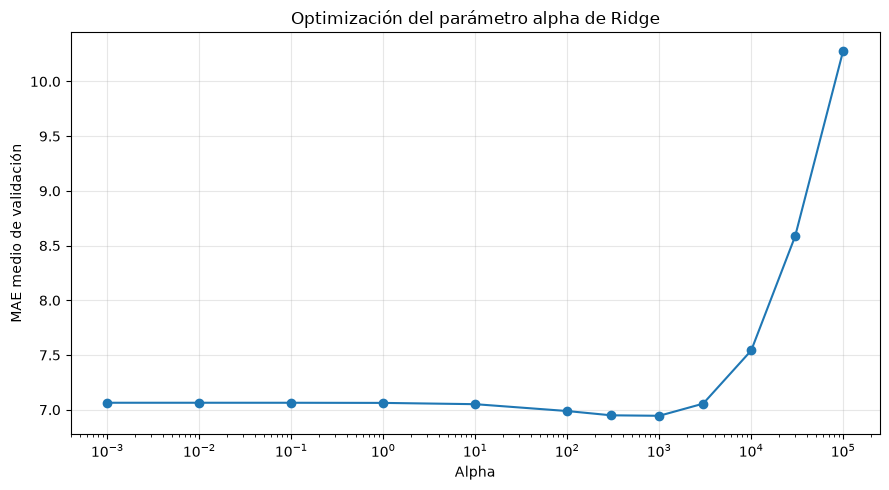

In [15]:
resultados_ridge_ordenados = (
    resumen_ridge
    .sort_values("param_modelo__alpha")
)

figura, eje = plt.subplots(
    figsize=(9, 5)
)

eje.plot(
    resultados_ridge_ordenados[
        "param_modelo__alpha"
    ],
    resultados_ridge_ordenados[
        "MAE_validacion"
    ],
    marker="o"
)

eje.set_xscale("log")
eje.set_title(
    "Optimización del parámetro alpha de Ridge"
)
eje.set_xlabel("Alpha")
eje.set_ylabel("MAE medio de validación")
eje.grid(True, alpha=0.3)

figura.tight_layout()

figura.savefig(
    RUTA_IMAGENES
    / "optimizacion_alpha_ridge.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

El mejor resultado se obtiene con `alpha = 1000`.

Los valores superiores comienzan a empeorar el MAE, por lo que el resultado no se encuentra simplemente en el límite de la búsqueda. La regularización elevada ayuda a controlar los coeficientes de un conjunto de variables correlacionadas y transformadas mediante One-Hot Encoding.

## 10. Optimización de HistGradientBoosting

Se utiliza `RandomizedSearchCV` para explorar una selección representativa de combinaciones sin ejecutar una búsqueda exhaustiva excesivamente costosa.

Se optimizan:

- Tasa de aprendizaje.
- Número máximo de iteraciones.
- Número máximo de hojas.
- Número mínimo de muestras por hoja.
- Regularización L2.

In [16]:
pipeline_hgb = Pipeline([
    (
        "preprocesado",
        preprocesador_arboles
    ),
    (
        "modelo",
        HistGradientBoostingRegressor(
            random_state=42
        )
    ),
])

parametros_hgb = {
    "modelo__learning_rate": [
        0.03,
        0.05,
        0.08,
        0.1,
    ],
    "modelo__max_iter": [
        100,
        200,
        300,
    ],
    "modelo__max_leaf_nodes": [
        15,
        31,
        63,
    ],
    "modelo__min_samples_leaf": [
        20,
        40,
        80,
    ],
    "modelo__l2_regularization": [
        0.0,
        0.1,
        1.0,
        10.0,
    ],
}

busqueda_hgb = RandomizedSearchCV(
    estimator=pipeline_hgb,
    param_distributions=parametros_hgb,
    n_iter=12,
    scoring="neg_mean_absolute_error",
    cv=folds_temporales,
    random_state=42,
    n_jobs=-1,
    return_train_score=True,
)

busqueda_hgb.fit(
    X_desarrollo,
    y_desarrollo
)

resultados_hgb = pd.DataFrame(
    busqueda_hgb.cv_results_
)

resultados_hgb["MAE_train"] = (
    -resultados_hgb["mean_train_score"]
)

resultados_hgb["MAE_validacion"] = (
    -resultados_hgb["mean_test_score"]
)

columnas_hgb = [
    "param_modelo__learning_rate",
    "param_modelo__max_iter",
    "param_modelo__max_leaf_nodes",
    "param_modelo__min_samples_leaf",
    "param_modelo__l2_regularization",
    "MAE_train",
    "MAE_validacion",
    "std_test_score",
]

resumen_hgb = (
    resultados_hgb[columnas_hgb]
    .sort_values("MAE_validacion")
    .reset_index(drop=True)
)

resumen_hgb

,param_modelo__learning_rate,param_modelo__max_iter,param_modelo__max_leaf_nodes,param_modelo__min_samples_leaf,param_modelo__l2_regularization,MAE_train,MAE_validacion,std_test_score
0,0.05,100,31,20,0.0,5.559979,7.061906,0.365691
1,0.05,300,15,20,0.1,5.213431,7.171475,0.395770
2,0.05,300,15,40,0.1,5.277792,7.173344,0.394135
3,0.05,200,31,40,0.1,4.832000,7.222069,0.413709
4,0.08,100,31,80,1.0,5.225921,7.224117,0.427827
5,0.10,200,15,20,10.0,5.022151,7.273264,0.477619
6,0.10,300,15,40,10.0,4.665753,7.369769,0.493058
7,0.08,300,15,20,0.1,4.725083,7.377565,0.533770
8,0.08,200,31,80,10.0,4.545677,7.410213,0.475400
9,0.10,100,63,20,0.1,3.887886,7.445055,0.399729


In [17]:
print("Mejores parámetros de HistGradientBoosting:")

for parametro, valor in busqueda_hgb.best_params_.items():
    print(parametro, ":", valor)

print(
    "\nMejor MAE medio de validación:",
    round(-busqueda_hgb.best_score_, 3)
)

Mejores parámetros de HistGradientBoosting:
modelo__min_samples_leaf : 20
modelo__max_leaf_nodes : 31
modelo__max_iter : 100
modelo__learning_rate : 0.05
modelo__l2_regularization : 0.0

Mejor MAE medio de validación: 7.062


## 11. Comparación final antes del test

Se comparan nuevamente:

- Baseline temporal.
- Ridge optimizado.
- HistGradientBoosting optimizado.

Esta comparación continúa utilizando exclusivamente train. Después de este paso, el modelo y sus hiperparámetros quedan bloqueados.

In [18]:
ridge_optimizado = Pipeline([
    (
        "preprocesado",
        preprocesador_lineal
    ),
    (
        "modelo",
        Ridge(alpha=1000)
    ),
])

hgb_optimizado = Pipeline([
    (
        "preprocesado",
        preprocesador_arboles
    ),
    (
        "modelo",
        HistGradientBoostingRegressor(
            learning_rate=0.05,
            max_iter=100,
            max_leaf_nodes=31,
            min_samples_leaf=20,
            l2_regularization=0.0,
            random_state=42
        )
    ),
])

modelos_finalistas = {
    "Ridge optimizado": ridge_optimizado,
    "HistGradientBoosting optimizado": hgb_optimizado,
}

In [19]:
resultados_finalistas = []

for fold, (
    indices_train,
    indices_validacion
) in enumerate(folds_temporales, start=1):

    datos_train_fold = train.loc[
        indices_train
    ].copy()

    datos_validacion_fold = train.loc[
        indices_validacion
    ].copy()

    X_train_fold = datos_train_fold[
        variables_modelo
    ]

    y_train_fold = datos_train_fold["no2"]

    X_validacion_fold = datos_validacion_fold[
        variables_modelo
    ]

    y_validacion_fold = datos_validacion_fold["no2"]

    pred_baseline = datos_validacion_fold[
        "no2_lag1"
    ]

    resultados_finalistas.append({
        "fold": fold,
        "modelo": "Baseline lag1",
        **calcular_metricas(
            y_validacion_fold,
            pred_baseline
        ),
        "tiempo_segundos": 0.0,
    })

    for nombre, modelo_base in modelos_finalistas.items():
        modelo = clone(modelo_base)

        inicio = time.time()

        modelo.fit(
            X_train_fold,
            y_train_fold
        )

        predicciones = modelo.predict(
            X_validacion_fold
        )

        resultados_finalistas.append({
            "fold": fold,
            "modelo": nombre,
            **calcular_metricas(
                y_validacion_fold,
                predicciones
            ),
            "tiempo_segundos": time.time() - inicio,
        })

resultados_finalistas_df = pd.DataFrame(
    resultados_finalistas
)

resultados_finalistas_df

,fold,modelo,MAE,RMSE,R2,tiempo_segundos
0,1,Baseline lag1,7.652073,10.735818,0.660932,0.000000
1,1,Ridge optimizado,7.017186,9.253808,0.748083,0.074777
2,1,HistGradientBoosting optimizado,7.558952,9.824091,0.716077,2.390999
3,2,Baseline lag1,8.109006,10.785466,0.579341,0.000000
4,2,Ridge optimizado,7.066408,9.563241,0.669278,0.111524
5,2,HistGradientBoosting optimizado,7.239083,9.971528,0.640436,2.780782
6,3,Baseline lag1,8.423024,11.412423,0.473024,0.000000
7,3,Ridge optimizado,6.947934,9.311366,0.649198,0.152196
8,3,HistGradientBoosting optimizado,6.845592,9.118952,0.663546,2.858637
9,4,Baseline lag1,7.628062,10.305213,0.426664,0.000000


In [20]:
resumen_finalistas = (
    resultados_finalistas_df
    .groupby("modelo")
    .agg(
        MAE_medio=("MAE", "mean"),
        MAE_std=("MAE", "std"),
        RMSE_medio=("RMSE", "mean"),
        R2_medio=("R2", "mean"),
        tiempo_medio=(
            "tiempo_segundos",
            "mean"
        ),
    )
    .sort_values("MAE_medio")
    .reset_index()
)

resumen_finalistas

,modelo,MAE_medio,MAE_std,RMSE_medio,R2_medio,tiempo_medio
0,Ridge optimizado,6.944956,0.139824,9.216208,0.663625,0.133200
1,HistGradientBoosting optimizado,7.061906,0.422264,9.390738,0.654065,2.854279
2,Baseline lag1,7.953041,0.383581,10.809730,0.534990,0.000000


### Modelo seleccionado

Se selecciona **Ridge con `alpha = 1000`** porque:

- Obtiene el menor MAE medio.
- Presenta la menor variabilidad entre folds temporales.
- Es considerablemente más rápido.
- Es más sencillo de interpretar.
- No muestra la misma diferencia entre train y validación observada en el modelo de boosting.

Una vez realizada esta selección, no se modifican el modelo, las variables ni los hiperparámetros utilizando información del conjunto de test.

## 12. Evaluación final sobre test

El pipeline Ridge se entrena con todo el conjunto de desarrollo y se evalúa sobre el test reservado.

Esta evaluación representa el rendimiento esperado sobre datos futuros no utilizados durante la selección del modelo.

In [21]:
X_train_final = train[variables_modelo]
y_train_final = train["no2"]

X_test_final = test[variables_modelo]
y_test_final = test["no2"]

modelo_final = clone(
    ridge_optimizado
)

modelo_final.fit(
    X_train_final,
    y_train_final
)

predicciones_test = modelo_final.predict(
    X_test_final
)

predicciones_baseline_test = test[
    "no2_lag1"
]

metricas_modelo_test = calcular_metricas(
    y_test_final,
    predicciones_test
)

metricas_baseline_test = calcular_metricas(
    y_test_final,
    predicciones_baseline_test
)

mejora_mae_porcentaje = (
    (
        metricas_baseline_test["MAE"]
        - metricas_modelo_test["MAE"]
    )
    / metricas_baseline_test["MAE"]
    * 100
)

resultados_test = pd.DataFrame([
    {
        "modelo": "Baseline lag1",
        **metricas_baseline_test,
    },
    {
        "modelo": "Ridge alpha=1000",
        **metricas_modelo_test,
    },
])

resultados_test

,modelo,MAE,RMSE,R2
0,Baseline lag1,7.216335,9.811211,0.589171
1,Ridge alpha=1000,6.959357,8.998921,0.654382


In [22]:
print(
    "Mejora del MAE frente al baseline:"
)

print(
    f"{mejora_mae_porcentaje:.2f}%"
)

print(
    "\nCobertura del conjunto de test:"
)

print(
    f"{cobertura_test:.2%}"
)

Mejora del MAE frente al baseline:
3.56%

Cobertura del conjunto de test:
99.77%


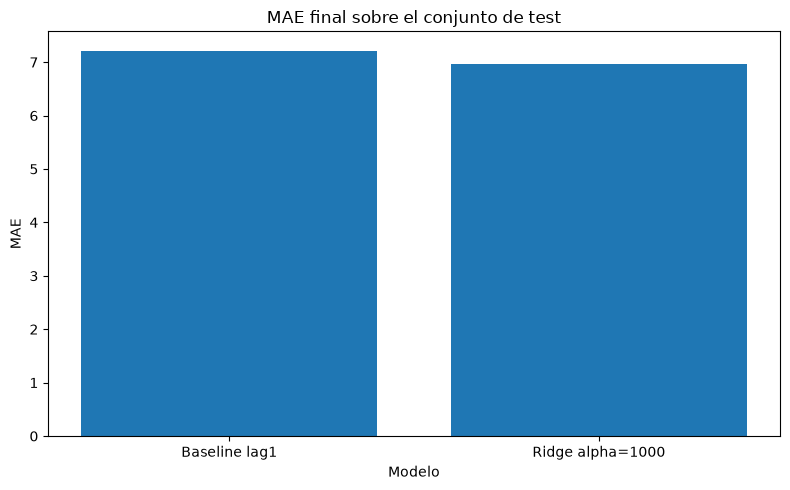

In [23]:
figura, eje = plt.subplots(
    figsize=(8, 5)
)

eje.bar(
    resultados_test["modelo"],
    resultados_test["MAE"]
)

eje.set_title(
    "MAE final sobre el conjunto de test"
)
eje.set_ylabel("MAE")
eje.set_xlabel("Modelo")

figura.tight_layout()

figura.savefig(
    RUTA_IMAGENES
    / "resultados_finales_test.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Lectura de los resultados

El MAE del modelo final se mantiene muy próximo al obtenido durante la validación temporal. Esto indica que el rendimiento estimado durante el desarrollo se reproduce sobre el periodo futuro reservado.

El baseline obtiene un resultado especialmente competitivo en test porque existe una fuerte persistencia temporal en la concentración de NO₂. Aun así, Ridge consigue reducir adicionalmente el error utilizando el resto de variables disponibles.

## 13. Análisis de los errores

Se estudia la distribución de los residuos y la relación entre los valores reales y las predicciones.

El residuo se define como:

`valor real - predicción`

In [24]:
analisis_test = test[
    [
        "fecha",
        "estacion",
        "no2",
    ]
].copy()

analisis_test["prediccion"] = (
    predicciones_test
)

analisis_test["residuo"] = (
    analisis_test["no2"]
    - analisis_test["prediccion"]
)

analisis_test["error_absoluto"] = (
    analisis_test["residuo"].abs()
)

analisis_test[
    [
        "residuo",
        "error_absoluto",
    ]
].describe()

,residuo,error_absoluto
count,10248.000000,10248.000000
mean,-2.571348,6.959357
std,8.624153,5.705358
min,-35.459441,0.000448
25%,-7.778195,2.655161
50%,-2.813625,5.544576
75%,2.404605,9.732978
max,41.599471,41.599471


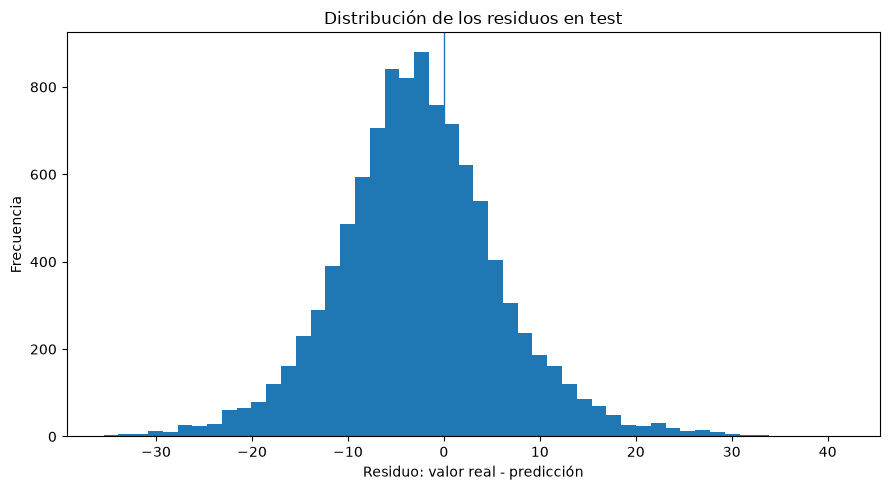

In [25]:
figura, eje = plt.subplots(
    figsize=(9, 5)
)

eje.hist(
    analisis_test["residuo"],
    bins=50
)

eje.axvline(
    0,
    linewidth=1
)

eje.set_title(
    "Distribución de los residuos en test"
)
eje.set_xlabel(
    "Residuo: valor real - predicción"
)
eje.set_ylabel("Frecuencia")

figura.tight_layout()

figura.savefig(
    RUTA_IMAGENES
    / "distribucion_residuos_test.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

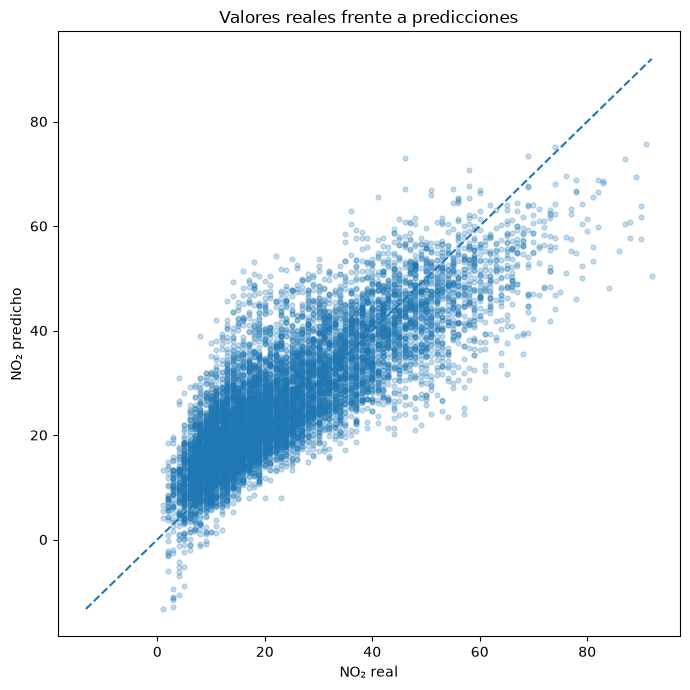

In [26]:
figura, eje = plt.subplots(
    figsize=(7, 7)
)

eje.scatter(
    analisis_test["no2"],
    analisis_test["prediccion"],
    alpha=0.25,
    s=12
)

limite_minimo = min(
    analisis_test["no2"].min(),
    analisis_test["prediccion"].min()
)

limite_maximo = max(
    analisis_test["no2"].max(),
    analisis_test["prediccion"].max()
)

eje.plot(
    [limite_minimo, limite_maximo],
    [limite_minimo, limite_maximo],
    linestyle="--"
)

eje.set_title(
    "Valores reales frente a predicciones"
)
eje.set_xlabel("NO₂ real")
eje.set_ylabel("NO₂ predicho")

figura.tight_layout()

figura.savefig(
    RUTA_IMAGENES
    / "real_vs_predicho_test.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [27]:
peores_predicciones = (
    analisis_test
    .sort_values(
        "error_absoluto",
        ascending=False
    )
    .head(15)
)

peores_predicciones

,fecha,estacion,no2,prediccion,residuo,error_absoluto
1360,2023-11-24,40,92,50.400529,41.599471,41.599471
1357,2023-11-24,36,84,48.083137,35.916863,35.916863
3502,2024-02-22,38,16,51.459441,-35.459441,35.459441
3494,2024-02-22,11,14,49.225898,-35.225898,35.225898
3501,2024-02-22,36,18,53.102306,-35.102306,35.102306
3944,2024-03-12,11,61,27.055163,33.944837,33.944837
10140,2024-11-26,40,65,31.714794,33.285206,33.285206
3954,2024-03-12,40,57,24.067188,32.932812,32.932812
3504,2024-02-22,40,18,50.827840,-32.827840,32.827840
1686,2023-12-08,40,17,49.747586,-32.747586,32.747586


## 14. Interpretabilidad del modelo

Como las variables numéricas se encuentran estandarizadas, sus coeficientes permiten comparar aproximadamente el peso de los cambios de una desviación estándar.

En las variables categóricas, cada coeficiente representa la diferencia respecto a la categoría de referencia implícita del conjunto codificado.

Un coeficiente positivo se asocia con un aumento de la predicción de NO₂ y uno negativo con una reducción, manteniendo constantes las demás variables.

Estas asociaciones no deben interpretarse automáticamente como relaciones causales.

In [28]:
nombres_variables_transformadas = (
    modelo_final
    .named_steps["preprocesado"]
    .get_feature_names_out()
)

coeficientes_modelo = (
    modelo_final
    .named_steps["modelo"]
    .coef_
)

importancia_coeficientes = pd.DataFrame({
    "variable": nombres_variables_transformadas,
    "coeficiente": coeficientes_modelo,
})

importancia_coeficientes[
    "valor_absoluto"
] = importancia_coeficientes[
    "coeficiente"
].abs()

importancia_coeficientes = (
    importancia_coeficientes
    .sort_values(
        "valor_absoluto",
        ascending=False
    )
    .reset_index(drop=True)
)

importancia_coeficientes.head(20)

,variable,coeficiente,valor_absoluto
0,numericas__no2_lag1,8.832330,8.832330
1,numericas__viento_vel,-2.981378,2.981378
2,numericas__dia_anio_cos,2.561999,2.561999
3,numericas__finde,-2.476598,2.476598
4,numericas__humedad,-2.110813,2.110813
5,categoricas__estacion_59,-1.665172,1.665172
6,categoricas__estacion_anio_primavera,-1.619058,1.619058
7,categoricas__estacion_56,1.562528,1.562528
8,numericas__no2_roll_mean_3,1.441690,1.441690
9,categoricas__estacion_49,-1.406400,1.406400


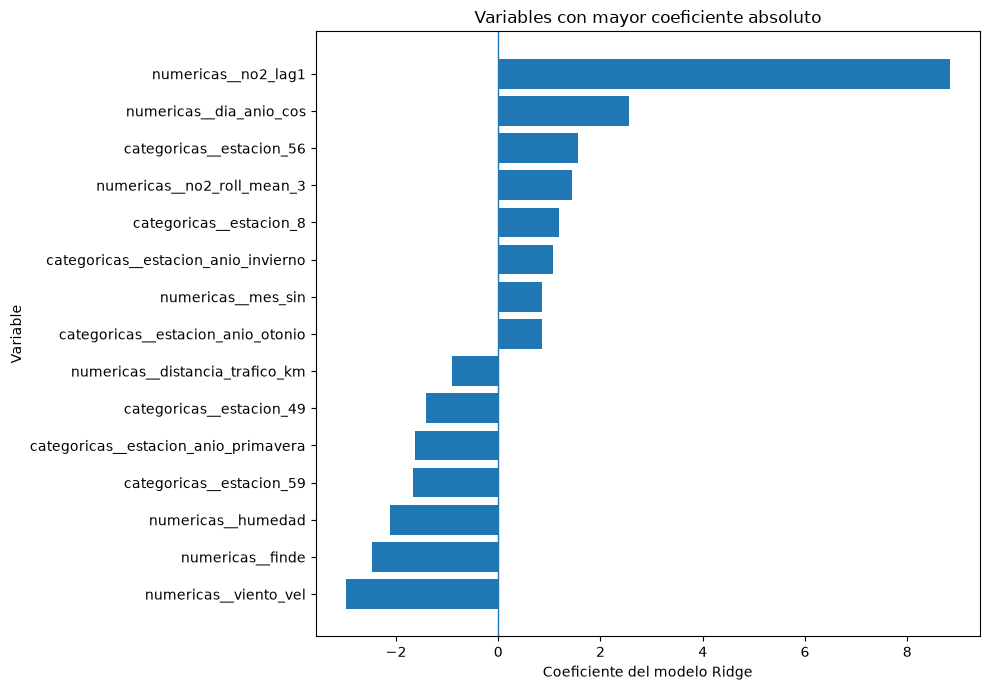

In [29]:
top_coeficientes = (
    importancia_coeficientes
    .head(15)
    .sort_values("coeficiente")
)

figura, eje = plt.subplots(
    figsize=(10, 7)
)

eje.barh(
    top_coeficientes["variable"],
    top_coeficientes["coeficiente"]
)

eje.axvline(
    0,
    linewidth=1
)

eje.set_title(
    "Variables con mayor coeficiente absoluto"
)
eje.set_xlabel(
    "Coeficiente del modelo Ridge"
)
eje.set_ylabel("Variable")

figura.tight_layout()

figura.savefig(
    RUTA_IMAGENES
    / "coeficientes_modelo_ridge.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Principales asociaciones aprendidas

Los resultados muestran que:

- `no2_lag1` es la referencia más importante, confirmando la persistencia temporal del contaminante.
- Una mayor velocidad del viento se asocia con menores concentraciones de NO₂, algo coherente con una mayor dispersión de contaminantes.
- Los fines de semana presentan una asociación negativa, posiblemente relacionada con una menor intensidad de tráfico.
- La estacionalidad anual, la humedad, la estación de medición y las medias móviles también aportan información.
- La influencia de una estación concreta debe interpretarse como una diferencia espacial respecto al resto de localizaciones representadas.

## 15. Guardado del pipeline final

Se guarda el pipeline completo, incluyendo:

- Imputación.
- Escalado.
- One-Hot Encoding.
- Modelo Ridge.

De esta forma, las nuevas observaciones pueden procesarse exactamente con las mismas transformaciones utilizadas durante el entrenamiento.

También se guarda un archivo JSON con las variables, periodos, cobertura y métricas principales.

In [30]:
ruta_modelo = (
    RUTA_MODELOS
    / "modelo_ridge_no2.joblib"
)

ruta_metadata = (
    RUTA_MODELOS
    / "modelo_ridge_no2_metadata.json"
)

joblib.dump(
    modelo_final,
    ruta_modelo
)

metadata = {
    "modelo": "Ridge",
    "alpha": 1000,
    "target": "no2",
    "metrica_principal": "MAE",
    "escenario": (
        "Predicción diaria utilizando la observación "
        "anterior disponible de NO2"
    ),
    "periodo_train": {
        "inicio": str(
            train["fecha"].min().date()
        ),
        "fin": str(
            train["fecha"].max().date()
        ),
    },
    "periodo_test": {
        "inicio": str(
            test["fecha"].min().date()
        ),
        "fin": str(
            test["fecha"].max().date()
        ),
    },
    "filas_train": int(len(train)),
    "filas_test_evaluadas": int(len(test)),
    "cobertura_test": float(cobertura_test),
    "variables_modelo": variables_modelo,
    "variables_excluidas": columnas_excluidas,
    "metricas_test": {
        clave: float(valor)
        for clave, valor
        in metricas_modelo_test.items()
    },
    "metricas_baseline_test": {
        clave: float(valor)
        for clave, valor
        in metricas_baseline_test.items()
    },
    "mejora_mae_porcentaje": float(
        mejora_mae_porcentaje
    ),
}

with open(
    ruta_metadata,
    "w",
    encoding="utf-8"
) as archivo:
    json.dump(
        metadata,
        archivo,
        ensure_ascii=False,
        indent=2
    )

print("Modelo guardado en:")
print(ruta_modelo)

print("\nMetadatos guardados en:")
print(ruta_metadata)

Modelo guardado en:
/Users/victoriabiancon/Desktop/ML_Contaminacion_Madrid/src/models/modelo_ridge_no2.joblib

Metadatos guardados en:
/Users/victoriabiancon/Desktop/ML_Contaminacion_Madrid/src/models/modelo_ridge_no2_metadata.json


## 16. Conclusiones de negocio

El modelo permite estimar la concentración diaria de NO₂ por estación utilizando información que puede estar disponible en un escenario operativo de seguimiento diario.

Su aplicación puede ayudar a:

- Anticipar jornadas con concentraciones elevadas.
- Apoyar la planificación de medidas preventivas.
- Identificar patrones meteorológicos, temporales y espaciales relacionados con el contaminante.
- Complementar sistemas de monitorización cuando existan retrasos puntuales en algunas fuentes de información.

El error medio final es cercano a 7 unidades de NO₂ y el modelo explica aproximadamente dos tercios de la variabilidad observada en el periodo futuro de test.

## 17. Limitaciones

1. El modelo necesita disponer de una observación anterior de NO₂. Por este motivo no puede generar una predicción para el primer registro de cada estación dentro de un bloque independiente.

2. `no2_lag1` representa la observación anterior disponible, que no siempre corresponde exactamente al día anterior cuando existen huecos en las fechas.

3. El modelo identifica asociaciones estadísticas, pero no demuestra relaciones causales.

4. Algunas variables de tráfico presentan un porcentaje elevado de valores ausentes.

5. El rendimiento puede cambiar ante modificaciones estructurales del tráfico, la meteorología, la normativa o la ubicación de las estaciones.

6. El pipeline debería monitorizarse y reentrenarse periódicamente cuando se incorporen nuevos datos.

## 18. Posibles mejoras futuras

- Crear lags basados explícitamente en fechas exactas.
- Incorporar el historial final de train al inicio de test para evitar perder la primera observación de cada estación.
- Evaluar modelos específicos de series temporales.
- Incorporar predicciones meteorológicas en lugar de variables observadas el mismo día.
- Añadir información sobre festivos, episodios extraordinarios y restricciones de tráfico.
- Aplicar técnicas de interpretabilidad local para analizar predicciones concretas.
- Implementar un sistema de monitorización del error y del cambio en la distribución de los datos.

## 19. Correspondencia con las fases del proyecto

Este notebook cubre las siguientes etapas:

- **25.** Selección y justificación de la métrica.
- **26.** Construcción del baseline.
- **27.** Comparación de modelos con validación cruzada.
- **28.** Selección de modelos candidatos.
- **29.** Búsqueda de hiperparámetros.
- **30.** Optimización utilizando exclusivamente train.
- **31.** Análisis de los resultados de validación.
- **32.** Evaluación final sobre test.
- **33.** Análisis de los errores.
- **34.** Interpretabilidad.
- **35.** Traducción de resultados al contexto del proyecto.
- **36.** Persistencia del modelo y sus metadatos.